# 02 - Direct Modeling

Notebook ini berisi tahap direct modeling untuk membangun model baseline awal pada proyek prediksi churn pelanggan.

Pada tahap ini, model dilatih tanpa preprocessing penuh dan tanpa hyperparameter tuning. Tujuannya adalah mendapatkan gambaran awal performa model sebelum dilakukan proses preprocessing dan optimasi pada tahap berikutnya.

Model yang digunakan:
1. Logistic Regression sebagai model konvensional.
2. Random Forest Classifier sebagai model ensemble bagging.
3. Voting Classifier sebagai model ensemble gabungan.

## Import Library

Library yang digunakan pada tahap ini mencakup library untuk membaca data, membagi data latih dan data uji, membangun model machine learning, serta melakukan evaluasi performa model.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## Setup Path Project

Path project disiapkan agar dataset dapat dibaca dari folder `data/raw` dan hasil evaluasi dapat disimpan ke folder `outputs`.

In [16]:
# Mengatur folder utama project
PROJECT_DIR = Path.cwd()

# Jika notebook dijalankan dari folder notebooks, arahkan ke folder utama project
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

# Path dataset dan folder output
DATA_PATH = PROJECT_DIR / "data" / "raw" / "Sales - Marketing customer dataset.csv"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
REPORTS_DIR = PROJECT_DIR / "outputs" / "reports"

# Membuat folder output jika belum tersedia
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/cahya/Project/UAS-BENGKOD-Churn-Prediction/data/raw/Sales - Marketing customer dataset.csv')

## Load Dataset

Dataset dibaca dari folder `data/raw`. Setelah itu dilakukan pengecekan awal untuk memastikan data berhasil dimuat dengan benar.

In [17]:
# Membaca dataset
df = pd.read_csv(DATA_PATH)

# Menampilkan 5 baris pertama
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [18]:
# Melihat jumlah baris dan kolom
df.shape

(15000, 30)

In [19]:
# Melihat informasi tipe data dan jumlah nilai non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## Menentukan Fitur dan Target

Kolom `churn` digunakan sebagai target prediksi. Semua kolom selain `churn` digunakan sebagai fitur prediktor.

Keterangan target:
- `0` = pelanggan tidak churn
- `1` = pelanggan churn

In [20]:
# Target prediksi
y = df["churn"]

# Fitur prediktor
X = df.drop(columns=["churn"])

print("Jumlah data:", X.shape[0])
print("Jumlah fitur:", X.shape[1])

print("\nDistribusi target:")
print(y.value_counts())

Jumlah data: 15000
Jumlah fitur: 29

Distribusi target:
churn
0    12702
1     2298
Name: count, dtype: int64


## Konversi Teknis Minimum

Dataset masih memiliki kolom kategorikal, kolom tanggal dalam bentuk object, dan beberapa nilai kosong. Model machine learning pada scikit-learn membutuhkan input numerik dan tidak dapat menerima missing value secara langsung.

Pada tahap direct modeling ini, data hanya dikonversi secara teknis agar model dapat dijalankan. Tahap ini belum dianggap sebagai preprocessing penuh karena belum dilakukan handling outlier, scaling, feature selection, maupun hyperparameter tuning.

In [21]:
# Membuat salinan data fitur untuk skenario direct modeling
X_direct = X.copy()

# Memisahkan kolom kategorikal dan numerik
categorical_cols = X_direct.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_direct.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Kolom kategorikal/object:")
print(categorical_cols)

print("\nKolom numerik:")
print(numerical_cols)

Kolom kategorikal/object:
['gender', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']

Kolom numerik:
['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


In [22]:
# Mengisi missing value secara sederhana agar model dapat menerima input
X_direct[categorical_cols] = X_direct[categorical_cols].fillna("Missing")
X_direct[numerical_cols] = X_direct[numerical_cols].fillna(-1)

# Mengubah kolom kategorikal menjadi numerik
X_direct = pd.get_dummies(X_direct, drop_first=False)

print("Shape setelah konversi teknis:", X_direct.shape)
X_direct.head()

Shape setelah konversi teknis: (15000, 1854)


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,...,subscription_type_Monthly,coupon_code_Missing,coupon_code_NEW20,coupon_code_REF10,coupon_code_SALE15,payment_method_BKash,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,10001,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,...,False,False,True,False,False,False,False,False,False,True
1,10002,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,...,True,False,True,False,False,True,False,False,False,False
2,10003,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,...,False,True,False,False,False,False,False,False,False,True
3,10004,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,...,False,True,False,False,False,False,False,True,False,False
4,10005,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,...,True,True,False,False,False,True,False,False,False,False


## Train-Test Split

Data dibagi menjadi data latih dan data uji dengan proporsi 80:20. Data latih digunakan untuk melatih model, sedangkan data uji digunakan untuk mengevaluasi kemampuan model pada data yang belum pernah dilihat sebelumnya.

Parameter `stratify=y` digunakan agar proporsi kelas churn dan tidak churn tetap seimbang pada data latih dan data uji.

In [23]:
# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_direct,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12000, 1854)
X_test: (3000, 1854)
y_train: (12000,)
y_test: (3000,)


## Menyiapkan Model

Tiga model digunakan untuk mewakili kategori model yang diminta pada skenario direct modeling.

- Logistic Regression digunakan sebagai model konvensional.
- Random Forest Classifier digunakan sebagai model ensemble bagging.
- Voting Classifier digunakan sebagai model ensemble gabungan dari beberapa model dasar.

Pada tahap ini model belum menggunakan hyperparameter tuning.

In [24]:
# Menyiapkan tiga model untuk direct modeling
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "Voting Classifier": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("nb", GaussianNB())
        ],
        voting="hard"
    )
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Voting Classifier': VotingClassifier(estimators=[('lr',
                               LogisticRegression(max_iter=1000, random_state=42,
                                                  solver='liblinear')),
                              ('dt', DecisionTreeClassifier(random_state=42)),
                              ('nb', GaussianNB())])}

## Training dan Evaluasi Model

Setiap model dilatih menggunakan data latih, kemudian diuji menggunakan data uji. Evaluasi dilakukan menggunakan beberapa metrik klasifikasi, yaitu accuracy, precision, recall, F1-score, dan confusion matrix.

Training model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2540
           1       0.29      0.05      0.08       460

    accuracy                           0.84      3000
   macro avg       0.57      0.51      0.50      3000
weighted avg       0.76      0.84      0.78      3000



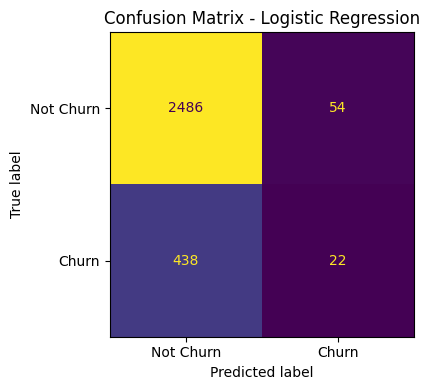

Training model: Random Forest
Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2540
           1       0.50      0.01      0.02       460

    accuracy                           0.85      3000
   macro avg       0.67      0.50      0.47      3000
weighted avg       0.79      0.85      0.78      3000



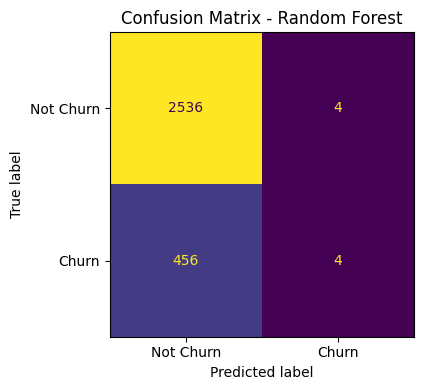

Training model: Voting Classifier
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2540
           1       0.47      0.19      0.27       460

    accuracy                           0.84      3000
   macro avg       0.67      0.57      0.59      3000
weighted avg       0.81      0.84      0.81      3000



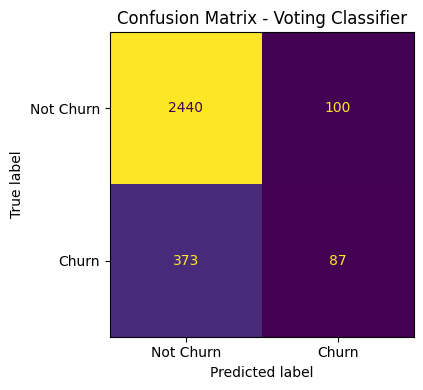

In [25]:
# List untuk menyimpan hasil evaluasi setiap model
results = []

# Melatih dan mengevaluasi setiap model
for model_name, model in models.items():
    print("=" * 60)
    print(f"Training model: {model_name}")
    
    # Melatih model menggunakan data latih
    model.fit(X_train, y_train)
    
    # Melakukan prediksi pada data uji
    y_pred = model.predict(X_test)
    
    # Menghitung metrik evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Menyimpan hasil evaluasi ke dalam list
    results.append({
        "Scenario": "Direct Modeling",
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
    
    # Menampilkan classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Membuat confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Churn", "Churn"]
    )
    disp.plot(ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    
    # Menyimpan gambar confusion matrix
    safe_model_name = model_name.lower().replace(" ", "_")
    plt.savefig(
        FIGURES_DIR / f"confusion_matrix_direct_{safe_model_name}.png",
        dpi=150,
        bbox_inches="tight"
    )
    
    plt.show()

## Hasil Evaluasi Direct Modeling

Hasil evaluasi dari setiap model disusun ke dalam tabel agar lebih mudah dibandingkan. Tabel ini nantinya akan menjadi baseline untuk dibandingkan dengan skenario preprocessing dan hyperparameter tuning.

In [26]:
# Mengubah hasil evaluasi menjadi dataframe
results_df = pd.DataFrame(results)

results_df

,Scenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct Modeling,Logistic Regression,0.836000,0.289474,0.047826,0.082090
1,Direct Modeling,Random Forest,0.846667,0.500000,0.008696,0.017094
2,Direct Modeling,Voting Classifier,0.842333,0.465241,0.189130,0.268934


In [27]:
# Menyimpan hasil evaluasi direct modeling
results_df.to_csv(REPORTS_DIR / "direct_modeling_results.csv", index=False)

print("Hasil evaluasi berhasil disimpan ke:")
print(REPORTS_DIR / "direct_modeling_results.csv")

Hasil evaluasi berhasil disimpan ke:
c:\Users\cahya\Project\UAS-BENGKOD-Churn-Prediction\outputs\reports\direct_modeling_results.csv


## Model Terbaik Sementara

Model terbaik sementara pada skenario direct modeling dipilih berdasarkan nilai F1-Score tertinggi. F1-Score digunakan karena target churn umumnya memiliki distribusi kelas yang tidak seimbang, sehingga accuracy saja belum cukup untuk menilai performa model.

In [28]:
# Memilih model terbaik sementara berdasarkan F1-Score
best_direct_model = results_df.sort_values(by="F1-Score", ascending=False).iloc[0]

best_direct_model

Scenario       Direct Modeling
Model        Voting Classifier
Accuracy              0.842333
Precision             0.465241
Recall                 0.18913
F1-Score              0.268934
Name: 2, dtype: object

## Kesimpulan Direct Modeling

Pada tahap direct modeling, tiga model telah dilatih dan dievaluasi sebagai baseline awal. Model yang digunakan adalah Logistic Regression, Random Forest Classifier, dan Voting Classifier.

Tahap ini bertujuan untuk melihat performa awal model sebelum dilakukan preprocessing penuh dan hyperparameter tuning. Hasil evaluasi dari tahap ini akan digunakan sebagai pembanding pada tahap berikutnya, yaitu modeling dengan preprocessing.

Hal utama yang dilakukan pada tahap ini:
- Menentukan `churn` sebagai target prediksi.
- Menggunakan seluruh kolom lain sebagai fitur prediktor.
- Melakukan train-test split.
- Melatih tiga model machine learning.
- Mengevaluasi model menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.
- Menyimpan hasil evaluasi dan confusion matrix.

Dari tahap ini, model belum dianggap sebagai model final. Model final akan dipilih setelah seluruh skenario selesai dibandingkan, yaitu direct modeling, preprocessing, dan hyperparameter tuning.